In [2]:
using JLD2, FileIO
using CairoMakie
using Printf
using Makie
using Dierckx

###########################
##### Summary #############
###########################

final_output = load("C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/summary_2_4.0e6_4.8e-7_100x100.jld2")
params = final_output["params"]
aux = final_output["aux"]

time = final_output["t"]/params["Gyr"]
TDE_rate = final_output["captures"][1] * params["Gyr"] * 1e-9
TDE_binary = final_output["captures"][2] * params["Gyr"] * 1e-9
#EMRI_rate = final_output["emri"][2] * params["Gyr"] * 1e-9
#DP_rate = final_output["captures"][2] * params["Gyr"] * 1e-9 - EMRI_rate

TDE_norm=TDE_rate/maximum(TDE_rate)
TDE_binary_norm=TDE_binary/maximum(TDE_binary)
#EMRI_norm=EMRI_rate/maximum(EMRI_rate)
#DP_norm=DP_rate/maximum(DP_rate)

lines(time, TDE_norm; axis=(xlabel=L"$t$ [Gyr]", ylabel = L"\dot{N} / \dot{N}_{\max}"), label="TDEs")
lines!(time, TDE_binary_norm, label="TDEs binary")
#lines!(time, DP_norm, label="Direct Plunges")
#lines!(time, EMRI_norm, label="EMRIs")
axislegend(current_axis(), position=:rb)

save("rates_4e6_2_0.1UA.pdf", current_figure())



###########################
##### Snapshots ###########
###########################

function trapz(x, y)
    sum( 0.5 * (y[1:end-1] .+ y[2:end]) .* diff(x) )
end

indices_snapshot = [1, 25, 50, 100, 120, 164]
colores = [:blue, :green, :orange, :red, :purple, :brown]

E = params["E0"] * (exp.(aux["s_val"]) .- 1.0)

for (i,color) in zip(indices_snapshot, colores)

    t = time[i*40]
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)

    E_copy = copy(E)
    y = E.*snap["diff_rate"][1] * params["Gyr"] * 1e-9

    sorted_indices = sortperm(y, rev=true)
    i1, i2 = sorted_indices[1], sorted_indices[2]
    y1, y2 = y[i1], y[i2]

    #Umbral, to consider that both of them are similar
    umbral = 0.4 * maximum(y)

    if abs(y1 - y2) < umbral
        x_peak = (E_copy[i1] + E_copy[i2]) / 2
        y_peak = 1.05 * maximum([y1, y2])  # 3% higher

        push!(E_copy, x_peak)
        push!(y, y_peak)

        orden = sortperm(E_copy)
        E_copy = E_copy[orden]
        y = y[orden]
    end
    
    N_dot_stars = trapz(log.(E_copy), y)
    @printf("The Ṅ (TDE) / real is: %.3f\n", N_dot_stars / TDE_rate[40*i])
    
    if i == 1
        lines(E_copy, y;
            axis=(; xscale=log10, xlabel=L"$E$ [$\sigma^2_\mathrm{inf}$]", ylabel=L"d $\dot{N}$/d$\log E$"), linestyle=:dash, color=color, label="t = $(round(t, digits=2)) Gyr")
    else
        lines!(E_copy, y; color=color, label="t = $(round(t, digits=2)) Gyr")
    end
end

xlims!(E[findfirst( aux["rc"] .< 10 * params["rh"] )], E[findfirst( aux["rc"] .< 0.001 * params["rh"] )])
axislegend(current_axis(), position=:rt)

vlines!(E[findfirst( aux["rc"] .< params["rh"] )])
text!(L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.0001))

save("differential_rate_stars_4e6_0.1UA_2comp.pdf", current_figure())

for (i,color) in zip(indices_snapshot, colores)

    t = time[i*40]
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    snap = load(snapshot_file)
    snap = load(snapshot_file)

    E_copy = copy(E)
    y = E.*snap["diff_rate"][2] * params["Gyr"] * 1e-9

    sorted_indices = sortperm(y, rev=true)
    i1, i2 = sorted_indices[1], sorted_indices[2]
    y1, y2 = y[i1], y[i2]

    #Umbral, to consider that both of them are similar
    umbral = 0.4 * maximum(y)

    if abs(y1 - y2) < umbral
        x_peak = (E_copy[i1] + E_copy[i2]) / 2
        y_peak = 1.05 * maximum([y1, y2])  # 3% higher

        push!(E_copy, x_peak)
        push!(y, y_peak)

        orden = sortperm(E_copy)
        E_copy = E_copy[orden]
        y = y[orden]
    end
    
    N_dot_stars = trapz(log.(E_copy), y)
    @printf("The Ṅ (binary) / real is: %.3f\n", N_dot_stars / TDE_binary[40*i])
    
    if i == 1
        lines(E_copy, y;
            axis=(; xscale=log10, xlabel=L"$E$ [$\sigma^2_\mathrm{inf}$]", ylabel=L"d $\dot{N}$/d$\log E$"), linestyle=:dash, color=color, label="t = $(round(t, digits=2)) Gyr")
    else
        lines!(E_copy, y; color=color, label="t = $(round(t, digits=2)) Gyr")
    end
end

xlims!(E[findfirst( aux["rc"] .< 10 * params["rh"] )], E[findfirst( aux["rc"] .< 0.001 * params["rh"] )])
axislegend(current_axis(), position=:rt)

ylims!(0, 0.0000012)
vlines!(E[findfirst( aux["rc"] .< params["rh"] )])
text!(L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.0000001))

save("differential_rate_binary_4e6_0.1UA_2comp.pdf", current_figure())

┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; interpreting Array{Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136}} as Array{Any}
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\datasets.jl:128
┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Main.#rho#136 does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:458
┌ Warning: type SuiteSparseGraphBLAS.GBMatrix{Float64,Float64} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Base.RefValue{Ptr{SuiteSparseGraphBLAS.LibGraphBLAS.GB_Matrix_opaque}} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\k

The Ṅ (TDE) / real is: 1.005
The Ṅ (TDE) / real is: 1.004
The Ṅ (TDE) / real is: 1.006
The Ṅ (TDE) / real is: 1.004
The Ṅ (TDE) / real is: 1.004
The Ṅ (TDE) / real is: 1.005
The Ṅ (binary) / real is: 1.003
The Ṅ (binary) / real is: 1.005
The Ṅ (binary) / real is: 1.006
The Ṅ (binary) / real is: 1.006
The Ṅ (binary) / real is: 1.005
The Ṅ (binary) / real is: 1.005


CairoMakie.Screen{PDF}


In [2]:
#We show the maximum rate of every channel

@printf "TDE peak is: %.3e\n" maximum(TDE_rate)
@printf "TDE peak time is: %.3e\n" time[1000:end][argmax(TDE_rate[1000:end])]
@printf "TDE peak time (binary) is: %.3e\n" time[argmax(TDE_binary)]
@printf "Total TDEs are: %.3e, Total TDE binaries are: %.3e\n" trapz(time.*1e9, TDE_rate) trapz(time.*1e9, TDE_binary)


TDE peak is: 3.820e-04
TDE peak time is: 6.065e-01
TDE peak time (binary) is: 1.600e+00
Total TDEs are: 8.412e+05, Total TDE binaries are: 3.496e+03


In [5]:
###########################
##### Combined Plot #######
###########################

max_stars = 0.0
max_bh = 0.0
snapshots_stars = Dict()
snapshots_bh = Dict()

indices_snapshot = [1, 50, 100, 150]
colores = [:blue, :green, :orange, :red]

for i in indices_snapshot
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    
    E_copy = copy(E)
    
    y_stars = E_copy .* snap["diff_rate"][1]
    y_bh = E_copy .* snap["diff_rate"][2]
    
    max_stars = max(max_stars, maximum(y_stars))
    max_bh = max(max_bh, maximum(y_bh))
    
    snapshots_stars[i] = (copy(E_copy), y_stars)
    snapshots_bh[i] = (copy(E_copy), y_bh)
end

f = Figure()
ax = Axis(f[1,1], xlabel=L"$E$ [$\sigma^2_\mathrm{inf}$]", ylabel=L"Normalized d $\dot{N}$/d$\log E$", xscale=log10)

for (i, color) in zip(indices_snapshot, colores)
    t = time[i*40]
    E_stars, y_stars = snapshots_stars[i]
    E_bh, y_bh = snapshots_bh[i]
    
    y_stars ./= max_stars
    y_bh ./= max_bh

    sorted_indices = sortperm(y_stars, rev=true)
    i1, i2 = sorted_indices[1], sorted_indices[2]
    if abs(y_stars[i1] - y_stars[i2]) < 0.4 * maximum(y_stars)
        x_peak = (E_stars[i1] + E_stars[i2]) / 2
        y_peak = 1.05 * max(y_stars[i1], y_stars[i2])
        push!(E_stars, x_peak)
        push!(y_stars, y_peak)
        orden = sortperm(E_stars)
        E_stars = E_stars[orden]
        y_stars = y_stars[orden]
    end

    sorted_indices = sortperm(y_bh, rev=true)
    i1, i2 = sorted_indices[1], sorted_indices[2]
    if abs(y_bh[i1] - y_bh[i2]) < 0.4 * maximum(y_bh)
        x_peak = (E_bh[i1] + E_bh[i2]) / 2
        y_peak = 1.05 * max(y_bh[i1], y_bh[i2])
        push!(E_bh, x_peak)
        push!(y_bh, y_peak)
        orden = sortperm(E_bh)
        E_bh = E_bh[orden]
        y_bh = y_bh[orden]
    end

    label = i == 1 ? "t = 0" : "t = $(round(t, digits=2)) Gyr"
    
    lines!(ax, E_stars, y_stars; linestyle=:dash, color=color, label="Stars, $label")
    lines!(ax, E_bh, y_bh; linestyle=:solid, color=color, label="BHs, $label")

end

xlims!(ax, E[findfirst( aux["rc"] .< 10 * params["rh"] )], E[findfirst( aux["rc"] .< 0.001 * params["rh"] )])
ylims!(ax, 0, 1.1)

vlines!(ax, E[findfirst( aux["rc"] .< params["rh"] )], linewidth = 2)
text!(ax, L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.7))

threshold = params["E0"] * (exp.(params["sGW"]) .- 1.0)
idx = findfirst(x -> x > threshold, E)
vlines!([E[idx]], color=:orange)
text!(L"r_{GW}", position = (1.1 * E[idx], 0.7))

axislegend(ax, position=:rt)

save("combined_differential_rate_1e6_3comp.pdf", f)

CairoMakie.Screen{PDF}


In [ ]:
#Dfs

In [8]:
f_initial = final_output["f0"]
s=aux["s_val"]
R=aux["R_val"]

fig = Figure(size=(800, 600))

ax1 = Axis(fig[1,1], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Initial DF for Binaries") 
ax2 = Axis(fig[1,3], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Initial DF for stars")  
ax3 = Axis(fig[2,1], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Final DF for Binaries")  
ax4 = Axis(fig[2,3], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Final DF for Stars")
#ax5 = Axis(fig[1,5], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Inditial DF for Binaries")  
#ax6 = Axis(fig[2,5], xlabel=L"s = \log \left(1 + \frac{E}{E_0} \right)", ylabel="R", title="Final DF for Binaries") 


#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Initial DF for BHs")


#hm = heatmap!(ax1, s, R, log10.(f0_matrix_transposed); colormap=:viridis, colorrange=(0, 3))
#Colorbar(fig[1,2], hm,  label = L"\log_{10}(f)")

#save("f0_BH_100x100.pdf", fig)

f0_matrix_s = reshape(f_initial[1] , 100, 100)
f0_matrix_transposed_s = f0_matrix_s'

#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Initial DF for stars")


hm = heatmap!(ax2, s, R, log10.(f0_matrix_transposed_s); colormap=:viridis, colorrange=(0, 5))
Colorbar(fig[1,4], hm,  label = L"\log_{10}(f)")

f0_matrix_b = reshape(f_initial[2] , 100, 100)
f0_matrix_transposed_b = f0_matrix_b'

#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Initial DF for stars")


hm = heatmap!(ax1, s, R, log10.(f0_matrix_transposed_b); colormap=:viridis, colorrange=(0, 5))
Colorbar(fig[1,2], hm,  label = L"\log_{10}(f)")


#save("f0_s_100x100.pdf", fig)

f_end = final_output["f_e"]
s=aux["s_val"]
R=aux["R_val"]
fe_matrix_s = reshape(f_end[1] , 100, 100)
fe_matrix_transposed_s = fe_matrix_s'


#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Final DF for stars")


hm = heatmap!(ax4, s, R, log10.(fe_matrix_transposed_s); colormap=:viridis, colorrange=(0, 5))
Colorbar(fig[2,2], hm,  label = L"\log_{10}(f)")

#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Final DF for BHs")

#hm = heatmap!(ax3, s, R, log10.(fe_matrix_transposed_BH); colormap=:viridis, colorrange=(0, 4))
#Colorbar(fig[2,4], hm,  label = L"\log_{10}(f)")

#save("fe_stars_100x100.pdf", fig)
fe_matrix_b = reshape(f_end[2] , 100, 100)
fe_matrix_transposed_b = fe_matrix_b'

#ax = Axis(fig[1, 1], xlabel="s", ylabel="R", title="Final DF for BHs")

hm = heatmap!(ax3, s, R, log10.(fe_matrix_transposed_b); colormap=:viridis, colorrange=(0, 5))
Colorbar(fig[2,4], hm,  label = L"\log_{10}(f)")

save("f_evol_4e6_2comp_0.1UA.pdf", fig)

CairoMakie.Screen{PDF}


In [ ]:
#f(s)

In [4]:
f0_marginalized_stars = sum(f0_matrix_transposed_s, dims=2)./50
#f0_marginalized_BH = sum(f0_matrix_transposed, dims=2)./40  
f0_marginalized_Binary = sum(f0_matrix_transposed_b, dims=2)./50   
fe_marginalized_stars = sum(fe_matrix_transposed_s, dims=2)./50
#fe_marginalized_BH = sum(fe_matrix_transposed_BH, dims=2)./40 
fe_marginalized_Binary = sum(fe_matrix_transposed_b, dims=2)./50 



f0_marginalized_stars = reshape(f0_marginalized_stars, length(s))
#f0_marginalized_BH = reshape(f0_marginalized_BH, length(s))
f0_marginalized_Binary = reshape(f0_marginalized_Binary, length(s))
fe_marginalized_stars = reshape(fe_marginalized_stars, length(s))
#fe_marginalized_BH = reshape(fe_marginalized_BH, length(s))
fe_marginalized_Binary = reshape(fe_marginalized_Binary, length(s))


fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel="s", ylabel="f(s)", title="f(s) vs s", yscale=log10,
    yticks=100.0 .^ (-4:7) )

ylims!(1e-4, 1e7)  


lines!(ax, s, f0_marginalized_stars, label="Stars 0 Gyr", color=:red, linewidth=2,linestyle=:dash)
lines!(ax, s, fe_marginalized_stars, label="Stars t=$(round(time[end], digits=5)) Gyr", color=:red, linewidth=2)
#lines!(ax, s, f0_marginalized_BH, label="BH 0 Gyr", color=:blue, linewidth=2,linestyle=:dash)
#lines!(ax, s, fe_marginalized_BH, label="BH t=$(round(time[end], digits=2)) Gyr", color=:blue, linewidth=2)
lines!(ax, s, f0_marginalized_Binary, label="Binaries 0 Gyr", color=:green, linewidth=2,linestyle=:dash)
lines!(ax, s, fe_marginalized_Binary, label="Binaries t=$(round(time[end], digits=5)) Gyr", color=:green, linewidth=2)

vlines!(s[findfirst( aux["rc"] .< 1.1 * params["rlc"][1] )])
text!(L"E_s", position = (1.01* s[findfirst( aux["rc"] .<  1.1*params["rlc"][1] )], 30))
vlines!(s[findfirst( aux["rc"] .< 1.18 * params["rlc"][2] )])
text!(L"E_{binary}", position = (1.01 * s[findfirst( aux["rc"] .< 1.18*params["rlc"][2] )], 30))

axislegend()

save("f(s)_1e6_2comp_0.1UA.pdf", fig)

CairoMakie.Screen{PDF}


In [5]:
#Consistency

f_end_s=final_output["f_e"][1].*aux["C"]

fe_matrix_s = reshape(f_end_s, 50, 100)
inner_integrals = [trapz(R, fe_matrix_s[:,i]) for i in 1:length(s)]
n_stars_f = trapz(E, inner_integrals)

f_initial_s=final_output["f0"][1].*aux["C"]

f0_matrix_s = reshape(f_initial_s, 50, 100)
inner_integrals = [trapz(R, f0_matrix_s[:,1]) for i in 1:length(s)]
n_stars_0 = trapz(E, inner_integrals)

println("Initial number of stars is: ", round(n_stars_0, digits=3))
println("Final is: ", round(n_stars_f, digits=3))
println("The difference is: ", round(n_stars_f-n_stars_0, digits=3))

f_end_bi=final_output["f_e"][2].*aux["C"]

fe_matrix_bi = reshape(f_end_bi, 50, 100)
inner_integrals = [trapz(R, fe_matrix_bi[:,i]) for i in 1:length(s)]
n_bi_f = trapz(E, inner_integrals)

f_initial_bi=final_output["f0"][2].*aux["C"]

f0_matrix_bi = reshape(f_initial_bi, 50, 100)
inner_integrals = [trapz(R, f0_matrix_bi[:,i]) for i in 1:length(s)]
n_bi_0 = trapz(E, inner_integrals)

println("Initial number of binaries is: ", round(n_bi_0, digits=3))
println("Final is: ", round(n_bi_f, digits=3))
println("The difference is: ", round(n_bi_f-n_bi_0, digits=3))

Initial number of stars is: 1.939769172325358e12
Final is: 1.8963751708e7
The difference is: -1.93975020857365e12
Initial number of binaries is: 9644.325
Final is: 8426.177
The difference is: -1218.148


In [ ]:
#n(r)

In [ ]:
using JLD2, FileIO
using CairoMakie
using Printf
using Makie

final_output_e = load("C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/density_1e5_3.jld2")
rho_stars = final_output_e["rho_stars"]
rho_bh = final_output_e["rho_bh"]
rho_binary = final_output_e["rho_binary"]
r=final_output_e["r"]
n_stars= rho_stars.*4*3.14.*r.^2
n_bh=rho_bh.*4*3.14.*r.^2
n_binary=rho_binary.*4*3.14.*r.^2

final_output_0 = load("C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/density_1e5_3_0.jld2")
rho_stars_0 = final_output_0["rho_stars"]
rho_bh_0 = final_output_0["rho_bh"]
rho_binary_0 = final_output_0["rho_binary"]
n_stars_0= rho_stars_0.*4*3.1416.*r.^2
n_bh_0=rho_bh_0.*4*3.1416.*r.^2
n_binary_0=rho_binary_0.*4*3.1416.*r.^2

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel = "r [pc]", ylabel = L"n_{r}(r)", title = "Radial density")
lines!(ax, log10.(r), log10.(n_stars), label = "stars t=$(round(time[end], digits=2)) Gyr", color = :red)
lines!(ax, log10.(r), log10.(n_bh), label = "BHs t=$(round(time[end], digits=2)) Gyr", color = :blue)
lines!(ax, log10.(r), log10.(n_binary), label = "Binaries t=$(round(time[end], digits=2)) Gyr", color = :green)
lines!(ax, log10.(r), log10.(n_stars_0), label = "stars t=0", color = :red, linestyle=:dash)
lines!(ax, log10.(r), log10.(n_bh_0), label = "BHs t=0", color = :blue, linestyle=:dash)
lines!(ax, log10.(r), log10.(n_binary_0), label = "Binaries t=0", color = :green, linestyle=:dash)

function trapz(x, y)
    sum( 0.5 * (y[1:end-1] .+ y[2:end]) .* diff(x) )
end

n_s_0 = trapz(n_stars_0, r)
n_s_f = trapz(n_stars, r)
@printf("N_stars init = %.4e, final = %.4e, Δ = %.4e\n", n_s_0, n_s_f, n_s_f - n_s_0)

n_b_0 = trapz(n_bh_0, r)
n_b_f = trapz(n_bh, r)
@printf("N_BHs   init = %.4e, final = %.4e, Δ = %.4e\n", n_b_0, n_b_f, n_b_f - n_b_0)

n_bi_0 = trapz(n_binary_0, r)
n_bi_f = trapz(n_binary, r)
@printf("N_Binary   init = %.4e, final = %.4e, Δ = %.4e\n", n_bi_0, n_bi_f, n_bi_f - n_bi_0)

axislegend()
vlines!(log10.(params["rh"]))
text!(L"r_h", position = ( log10.(params["rh"]), 5), fontsize=16)

r0= 1e-4*params["rh"]
r1 = 1e-3*params["rh"]
r2 = 1e2*params["rh"]
r3 = 1e4*params["rh"]
r4 = 1*params["rh"]
r5 = 0.1*params["rh"]

idx1 = findall(r0 .< r .< r1)
idx2 = findall(r2 .< r .< r3)
idx3 = findall(r5 .< r .< r4)
print(idx3)

# Fit en log-log (línea recta en log-log: log(y) = α*log(x) + b)
logr1, logy1 = log10.(r[idx1]), log10.(n_stars[idx1])
logr2, logy2 = log10.(r[idx2]), log10.(n_stars[idx2])
logy3 = log10.(n_bh[idx1])
logy4 = log10.(n_bh[idx2])
logy5 = log10.(n_stars_0[idx1])
logy6 = log10.(n_bh_0[idx1])
logr3, logy7 = log10.(r[idx3]), log10.(n_binary[idx3])
logy8 = log10.(n_binary[idx2])
logy9 = log10.(n_binary_0[idx3])

function fit(x, y)
    A = [x ones(length(x))]
    coeffs = A \ y
    return coeffs[1], coeffs[2]
end

α1, b1 = fit(logr1, logy1)
α2, b2 = fit(logr2, logy2)
α3, b3 = fit(logr1, logy3)
α4, b4 = fit(logr2, logy4)
α5, b5 = fit(logr1, logy5)
α6, b6 = fit(logr1, logy6)
α7, b7 = fit(logr3, logy7)
α8, b8 = fit(logr2, logy8)
α9, b9 = fit(logr3, logy9)

logr_fit1 = range(extrema(logr1)..., length=100)
logr_fit2 = range(extrema(logr2)..., length=100)
logr_fit3 = range(extrema(logr3)..., length=100)

logn_fit1 = α1 .* logr_fit1 .+ b1
logn_fit2 = α2 .* logr_fit2 .+ b2
logn_fit3 = α3 .* logr_fit1 .+ b3
logn_fit4 = α4 .* logr_fit2 .+ b4
logn_fit5 = α5 .* logr_fit1 .+ b5
logn_fit6 = α6 .* logr_fit1 .+ b6
logn_fit7 = α7 .* logr_fit3 .+ b7
logn_fit8 = α8 .* logr_fit2 .+ b8
logn_fit9 = α9 .* logr_fit3 .+ b9

lines!(ax, logr_fit1, logn_fit1, color = :black)
lines!(ax, logr_fit2, logn_fit2, color = :black)
lines!(ax, logr_fit1, logn_fit3, color = :black)
lines!(ax, logr_fit2, logn_fit4, color = :black)
lines!(ax, logr_fit1, logn_fit5, color = :black)
lines!(ax, logr_fit1, logn_fit6, color = :black)
lines!(ax, logr_fit3, logn_fit7, color = :black)
lines!(ax, logr_fit2, logn_fit8, color = :black)
lines!(ax, logr_fit3, logn_fit9, color = :black)

x1_text, y1_text = logr_fit1[end], logn_fit1[end]
x2_text, y2_text = logr_fit2[1], logn_fit2[1]
x3_text, y3_text = logr_fit1[end], logn_fit3[end]
x4_text, y4_text = logr_fit2[1], logn_fit4[1]
x5_text, y5_text = logr_fit1[end], logn_fit5[end]
x6_text, y6_text = logr_fit1[end], logn_fit6[end]
x7_text, y7_text = logr_fit3[end], logn_fit7[end]
x8_text, y8_text = logr_fit2[1], logn_fit8[1]
x9_text, y9_text = logr_fit3[end], logn_fit9[end]


xlims!(-5,4)
ylims!(-2,7)
text!(ax, "α = $(round(α1, digits=2))", position = (x1_text, y1_text), align = (:left, :bottom), fontsize=16)
text!(ax, "β = $(round(α2, digits=2))", position = (x2_text, y2_text), align = (:left, :bottom), fontsize=16)
text!(ax, "α = $(round(α3, digits=2))", position = (x3_text, y3_text), align = (:left, :bottom), fontsize=16)
text!(ax, "β = $(round(α4, digits=2))", position = (x4_text, y4_text), align = (:left, :bottom), fontsize=16)
text!(ax, "α = $(round(α5, digits=2))", position = (x5_text, y5_text), align = (:left, :bottom), fontsize=16)
text!(ax, "α = $(round(α6, digits=2))", position = (x6_text, y6_text), align = (:left, :bottom), fontsize=16)
text!(ax, "α = $(round(α7, digits=2))", position = (x7_text, y7_text), align = (:left, :bottom), fontsize=16)
text!(ax, "β = $(round(α8, digits=2))", position = (x8_text, y8_text), align = (:left, :bottom), fontsize=16)
text!(ax, "α = $(round(α9, digits=2))", position = (x9_text, y9_text), align = (:left, :bottom), fontsize=16)

save("n(r)_1e5_3.pdf", fig)

In [ ]:
#what about q

In [61]:
indices_snapshot = [1, 50, 100, 120, 164]
colores = [:blue, :green, :orange, :red, :purple]

for (i,color) in zip(indices_snapshot, colores)
    t = time[i*40]
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    q=snap["q"]
    if i == 1
        lines(E, q[1];
            axis=(; xscale=log10, yscale=log10, xlabel = "E", ylabel = L"q(E)"), color=color, label="t = $(round(t, digits=2)) Gyr",linewidth=1)
    else
        lines!(E, q[1]; color=color, label="t = $(round(t, digits=2)) Gyr",linewidth=1)
    end
end

vlines!(E[findfirst( aux["rc"] .< params["rh"] )])
text!(L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.0001))

axislegend(current_axis(), position=:rt)
save("q(E)_stars_4e6_0.1UA.pdf",  current_figure())

for (i,color) in zip(indices_snapshot, colores)
    t = time[i*40]
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    q=snap["q"]
    if i == 1
        lines(E, q[2];
            axis=(; xscale=log10, yscale=log10, xlabel = "E", ylabel = L"q(E)"), color=color, label="t = $(round(t, digits=2)) Gyr",linewidth=1)
    else
        lines!(E, q[2]; color=color, label="t = $(round(t, digits=2)) Gyr",linewidth=1)
    end
end

vlines!(E[findfirst( aux["rc"] .< params["rh"] )])
text!(L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.0001))

axislegend(current_axis(), position=:rt)
save("q(E)_sBHBs_4e6_0.1UA.pdf",  current_figure())

CairoMakie.Screen{PDF}


In [ ]:
#dist of a and e

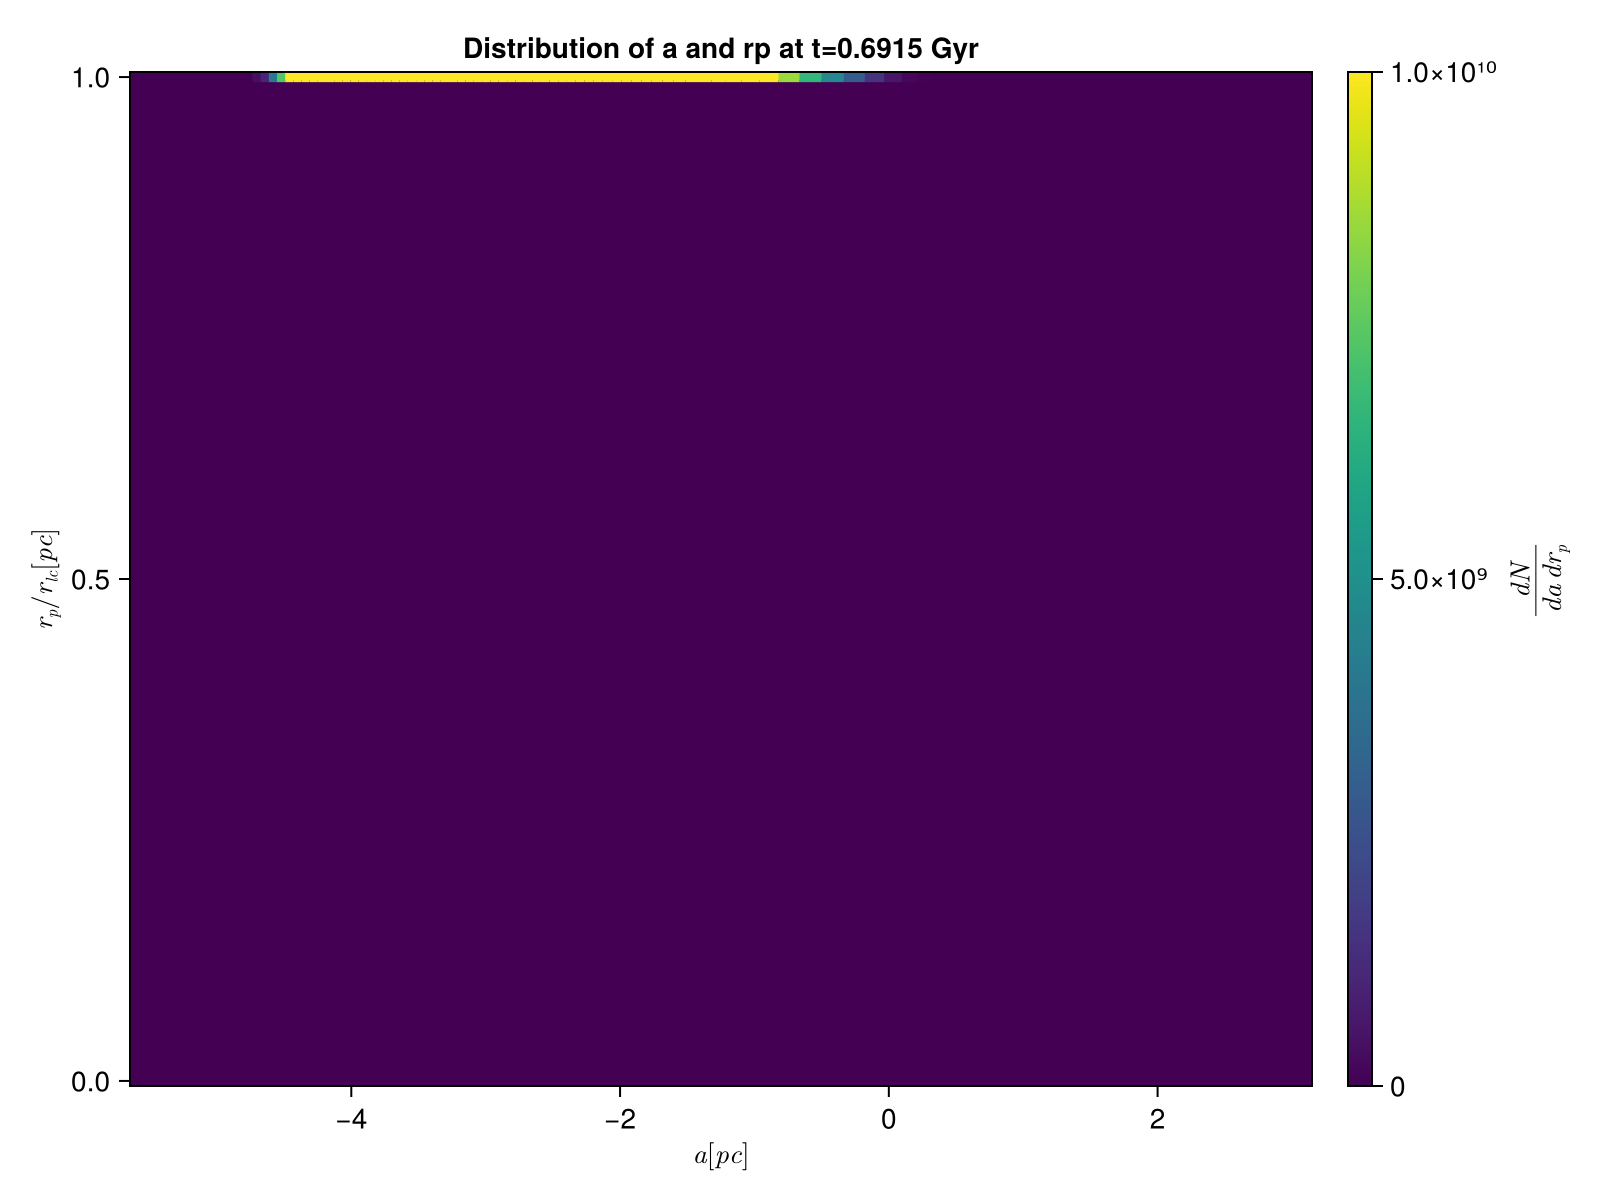

CairoMakie.Screen{PDF}


In [6]:
using SpecialFunctions
using LinearAlgebra

dEda = zeros(length(E))
dEda[2:end-1] .= (E[3:end] - E[1:end-2]) ./ (aux["rc"][3:end] - aux["rc"][1:end-2])

dEda[1] = (E[2] - E[1]) / (aux["rc"][2] - aux["rc"][1])  
dEda[end] = (E[end] - E[end-1]) / (aux["rc"][end] - aux["rc"][end-1])

function besseli_leo(x,y)
    return besseli(0, x)./besseli(1, y)
end

dN_dEdt=[]
t=[]
q_t=[]

indices_snapshot = 1:114

for i in indices_snapshot

    push!(t,time[i*40])
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_1.0e6_4.8e-7/snap_grid_50x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    push!(dN_dEdt,snap["diff_rate"][2] * params["Gyr"])
    push!(q_t, snap["q"][2])
    
end


q_t=reduce(vcat, q_t')

dN_dEdt = Matrix(reduce(hcat, dN_dEdt)')

#dN_dE = [trapz(t, y[:,i]) for i in 1:length(s)]

N_E = length(E)
r_LC = final_output["params"]["rlc"][2]
#q_E = q_0[3]

N_rp = 100
r_p = range(0, r_LC; length=N_rp)
dx = step(r_p)

dNdrpdEdt = zeros(N_E, length(indices_snapshot), N_rp)


for i in 1:N_E
    q = q_t[:,i]
    dNdrp_matrix = zeros(length(indices_snapshot), length(r_p))
    for j in indices_snapshot
        arg = @. 2 * sqrt.(r_p ./ (q[j] * r_LC))
        norm = 2 / sqrt(q[j])
        if q[j] < 0.01
            dN_drp = zeros(length(r_p))
            x0 = r_LC
            ix = findall(abs.(r_p .- x0) .< dx/2)
            dN_drp[ix] .= 1 / dx
        elseif q[j] > 10
            dN_drp = fill(1/r_LC, length(r_p))
        else
            dN_drp = (1/(r_LC*sqrt(q[j]))) .* @.besseli_leo(arg, norm)
        end
        dNdrp_matrix[j, :] .= dN_drp
    end
    dNdrpdEdt[i, :, :] = dN_dEdt[:,i] .* dNdrp_matrix
end

dNdrpdE = [trapz(t, dNdrpdEdt[i, :, j]) for i in 1:length(E), j in 1:length(r_p)]

dNdrpdE[isnan.(dNdrpdE)] .= 0
dNdrpdE[dNdrpdE .< 0] .= 0

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel=L"a [pc]", ylabel=L"r_{p}/r_{lc} [pc]", title="Distribution of a and rp at t=$(round(t[end], digits=5)) Gyr")
hm = heatmap!(ax, log10.(aux["rc"]), r_p/r_LC, dNdrpdE.*abs.(dEda .* ones(1, length(r_p))); colormap=:viridis, colorrange=(0, 1e10))
Colorbar(fig[1,2], hm,  label = L"\frac{dN}{da \, dr_p}")
display(fig)

save("a and rp_1e6_2_0.1UA.pdf", fig)

In [30]:
using Distributions

#obtain the values of lamba
t_new=vcat(0,t)
dt = diff(t_new*1e9)
sub_TDE_binary=TDE_binary[1:40:end]
lambas=sub_TDE_binary[1:114].*dt
max_ind = findall(x -> 0.2 <= x <= 0.3, t_new) 
realizations= 1:20
TDE_final=[]
for j in realizations
    Total_TDE=[]
    for i in lambas
        y=rand(Poisson(i))
        push!(Total_TDE,y)
    end
    push!(TDE_final,Total_TDE[max_ind])
end

#fig = Figure(resolution = (1000, 400))  
#ax = Axis(fig[1, 1])
#lines!(ax, t, Total_TDE)
#fig


In [38]:

using Random, Interpolations


accepted_energies_final=[]
#accepted_a = Vector{Vector{Float64}}(undef, length(Total_TDE))
itp_Rc = interpolate((E,), aux["rc"], Gridded(Linear()))
for j in realizations
    accepted_energies = []
    for i in max_ind
        itp = interpolate((log10.(E),), dN_dEdt[i,:], Gridded(Linear()))
        
        p_max = maximum(dN_dEdt[i,:])
    
        N_TDE = TDE_final[j][i-minimum(max_ind)+1]
        E_min = minimum(log10.(E))
        E_max = maximum(log10.(E))
    
        Ei = Float64[]
        #ai = Float64[]
        
        while length(Ei) < N_TDE
            E_trial = rand() * (E_max - E_min) + E_min
            y = rand() * p_max
            if y < itp(E_trial)
                #push!(ai, itp_Rc[10^E_trial])
                push!(Ei, -(10^(E_trial)-params["phis0"]))
            end
        end
    
        push!(accepted_energies, Ei)
        #accepted_a[i] = ai
    end
    push!(accepted_energies_final, accepted_energies)
end



In [14]:


using SpecialFunctions
using LinearAlgebra

function besseli_leo(x,y)
    return besseli(0, x)./besseli(1, y)
end

r_LC = final_output["params"]["rlc"][2]
N_rp = 100
r_p = range(0, r_LC; length=N_rp)

acepted_rp_total=[]
acepted_B_total=[]

for k in realizations
    accepted_rp = []
    accepted_B = []
    for i in max_ind
        snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_1.0e6_4.8e-7/snap_grid_50x100_$(@sprintf("%03d", i)).jld2"
        snap = load(snapshot_file)
        energies = accepted_energies_final[k][i-minimum(max_ind)+1]
        q_E = snap["q"][2]
        itp_qE = interpolate((E,), q_E, Gridded(Linear()))
        rp= Float64[]
        B= Float64[]
        for j in energies
            q=itp_qE[-(j)+params["phis0"]]
            arg = @. 2 * sqrt.(r_p ./ (q * r_LC))
            norm = 2 / sqrt(q)
            if q < 0.01
                push!(rp,r_LC)
                push!(B, 1)
            elseif q > 10
                push!(rp, rand() * r_LC)
                push!(B, r_LC / (rand() * r_LC))
            else
                dN_drp = (1/(r_LC*sqrt(q))) .* @.besseli_leo(arg, norm)
                while true  
                    itp_rp = interpolate((collect(r_p),), dN_drp, Gridded(Linear()))
                    rp_trial = rand() * r_LC
                    p_max = maximum(dN_drp)
                    y = rand() * p_max
                    p_max = maximum(dN_drp)
                    if y < itp_rp(rp_trial)
                        push!(rp, rp_trial)
                        push!(B, r_LC/rp_trial)
                        break
                    end
                end
            end
        push!(accepted_rp,rp)
        push!(accepted_B,B)
        end
    end
    push!(acepted_rp_total, accepted_rp)
    push!(acepted_B_total, accepted_B)
end


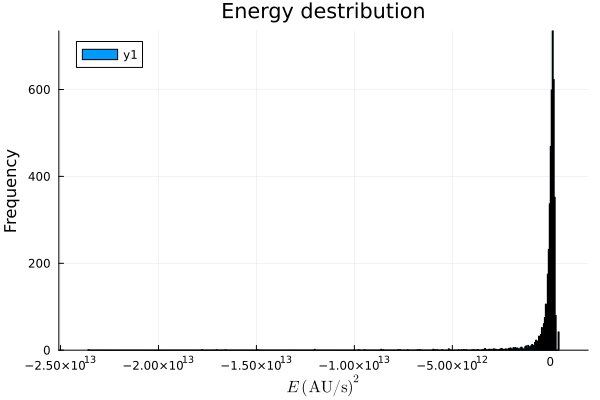

In [15]:
#Ditb de a
using Plots 

sublistas = vcat(accepted_energies_final...)

E_dist = [x for lista in sublistas if !isempty(lista) for x in lista]

plt = histogram((E_dist*(1/4.8e-6)^2); bins=500, xlabel=L"E\;(\mathrm{AU} / \mathrm{s})^2", ylabel="Frequency", title="Energy destribution")
display(plt)

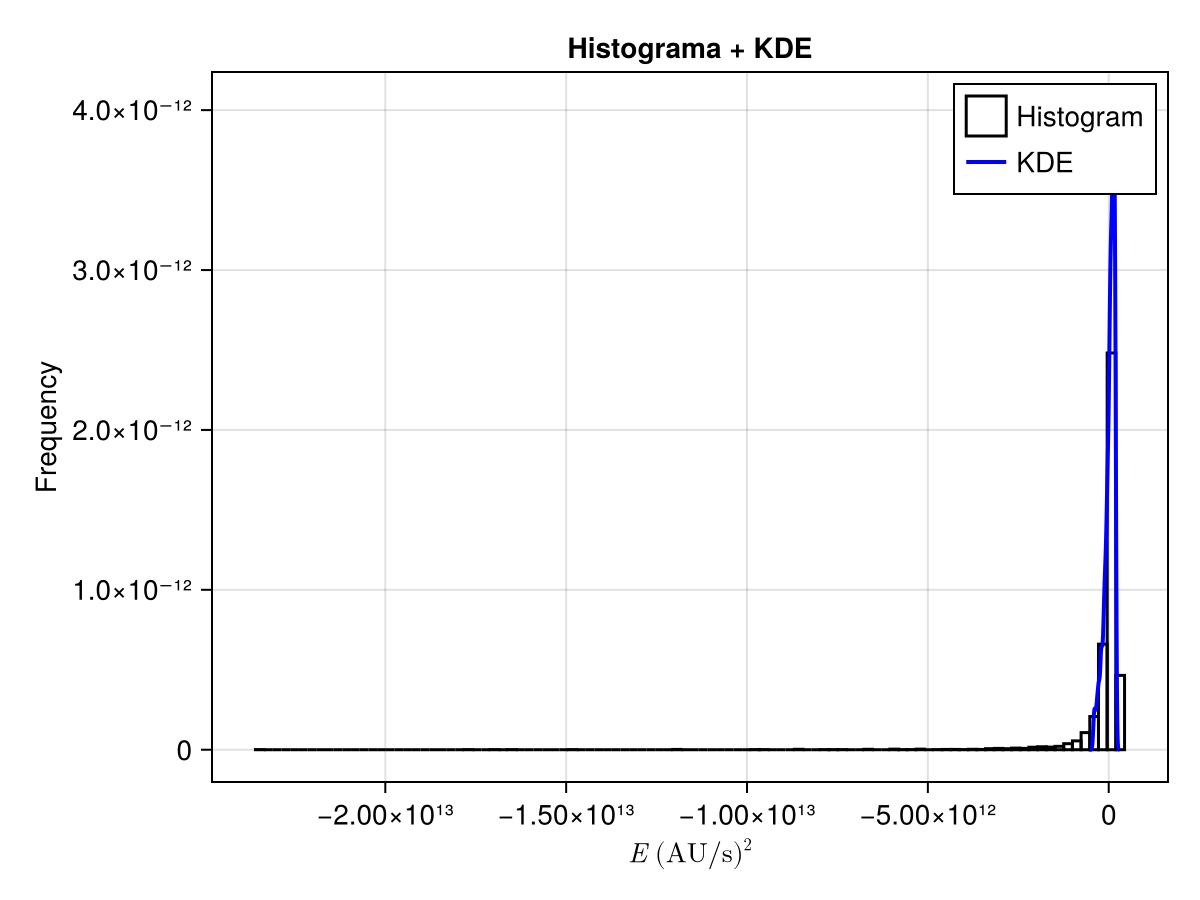

226-element Vector{Float64}:
  5.4724102605177414e10
  4.04924825603461e10
  1.760881957652667e11
  1.8992449303107492e11
 -7.217450946123515e10
  1.8359932856670544e11
  8.86666023849873e9
  8.555927936897859e10
 -7.098854112416588e10
  1.3610533586775835e10
  4.998022925690031e10
  3.4167318095976624e10
  1.3181204451468037e11
  ⋮
  7.52808871143782e10
  3.298134975890735e10
 -6.98025727870966e10
  5.308755227290901e9
  1.606706073833661e11
 -6.946250922424953e9
 -2.986944618414669e11
  3.891119144425373e10
 -2.1330474157247903e11
  1.3892785453709604e11
  1.1955703836496452e11
  1.5395012013997354e11

In [17]:
using KernelDensity, StatsBase, Random


E_scaled = (E_dist*(1/4.8e-6)^2)

p_low, p_high = quantile(E_scaled, [0.1, 0.9])
E_cut = E_scaled[(E_scaled .>= p_low) .& (E_scaled .<= p_high)]

kde_result = kde(E_cut)  


x_vals = kde_result.x
pdf_vals = kde_result.density

fig = Figure()
ax = Axis(fig[1, 1]; xlabel=L"E\;(\mathrm{AU} / \mathrm{s})^2", ylabel="Frequency", title="Histograma + KDE")

# Histogram
hist!(ax, E_scaled; bins=100, normalization=:pdf, color=:transparent, strokecolor=:black, strokewidth=1.5, label="Histogram")

# KDE
lines!(ax, x_vals, pdf_vals; color=:blue, linewidth=2, label="KDE")

axislegend(ax)
display(fig)

#println("The best witdh: ", kde_result.bandwidth)

#sampling
pdf_vals_norm = pdf_vals ./ sum(pdf_vals)

N = ceil(Int, (sum(sum(TDE_final))/length(realizations)))  # number of samplings
samples_E = sample(x_vals, Weights(pdf_vals_norm), N)
samples_E

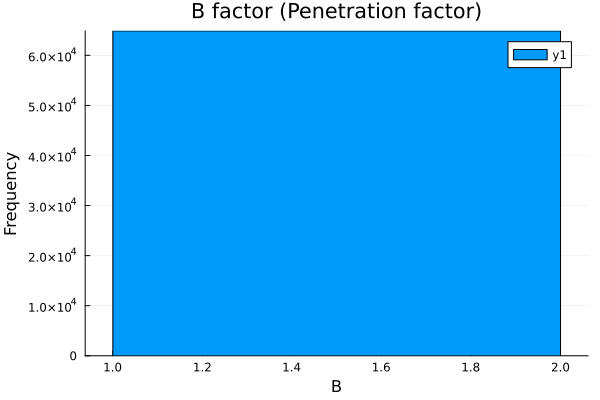

In [27]:
#Ditb de B

sublistas = vcat(acepted_B_total...)

B_dist = [x for lista in sublistas if !isempty(lista) for x in lista]

plt = histogram(B_dist; bins=10000, xlabel="B", ylabel="Frequency", title="B factor (Penetration factor)")
display(plt)


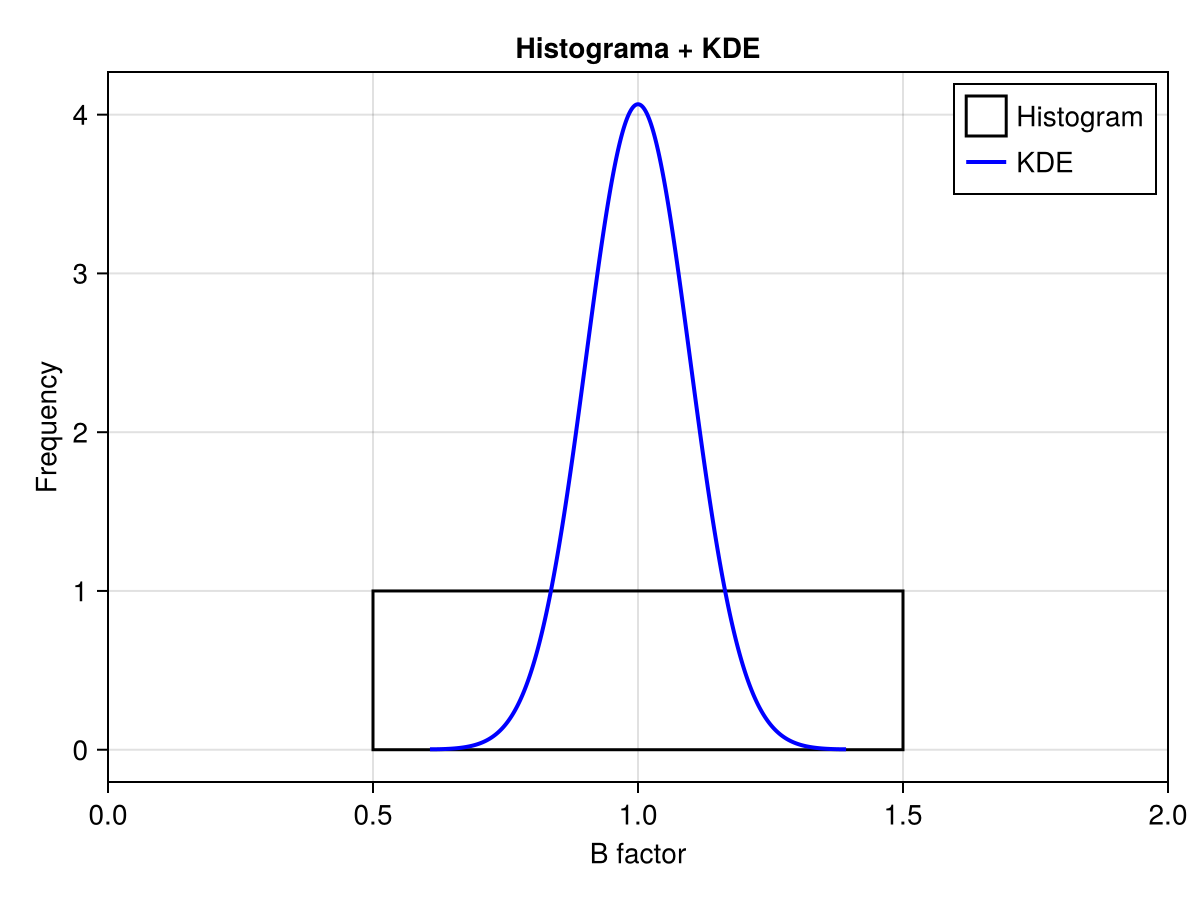

226-element Vector{Float64}:
 0.9595387225489834
 0.9675926261174322
 0.9580046456788027
 0.9016273206996612
 0.8318268231064383
 1.0477481425843749
 0.9058460320926581
 0.9449649922822666
 1.056185565370369
 0.9790982026437877
 0.9453485114998118
 0.94151331932436
 1.132889408879405
 ⋮
 0.9952060097806853
 1.1466961007110317
 0.9998082403912274
 0.9484166652401732
 0.8256905156257154
 0.9890697022999624
 1.1367246010548568
 0.7957760166571913
 1.1229179092232304
 1.0017258364789534
 0.9311583004506401
 1.0005752788263178

In [22]:
p_low, p_high = quantile(B_dist, [0.1, 0.9])
B_cut = B_dist[(B_dist .>= p_low) .& (B_dist .<= p_high)]

kde_result = kde(B_cut)  

x_vals = kde_result.x
pdf_vals = kde_result.density

fig = Figure()
ax = Axis(fig[1, 1]; xlabel="B factor", ylabel="Frequency", title="Histograma + KDE", limits=(0, 2, nothing, nothing))

# Histogram
hist!(ax, B_dist; bins=1000, normalization=:pdf, color=:transparent, strokecolor=:black, strokewidth=1.5, label="Histogram")

# KDE
lines!(ax, x_vals, pdf_vals; color=:blue, linewidth=2, label="KDE")

axislegend(ax)
display(fig)

pdf_vals_norm = pdf_vals ./ sum(pdf_vals)

samples_B = sample(x_vals, Weights(pdf_vals_norm), N)
samples_B

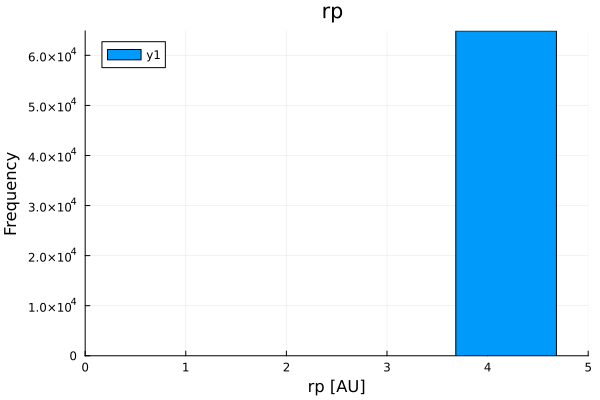

In [24]:
#Ditb de rp

sublistas = vcat(acepted_rp_total...)

rp_dist = [x for lista in sublistas if !isempty(lista) for x in lista]

plt = histogram(rp_dist/4.8e-6; bins=50, xlabel="rp [AU]", ylabel="Frequency", title="rp ", xlims = (0, 5))
display(plt)

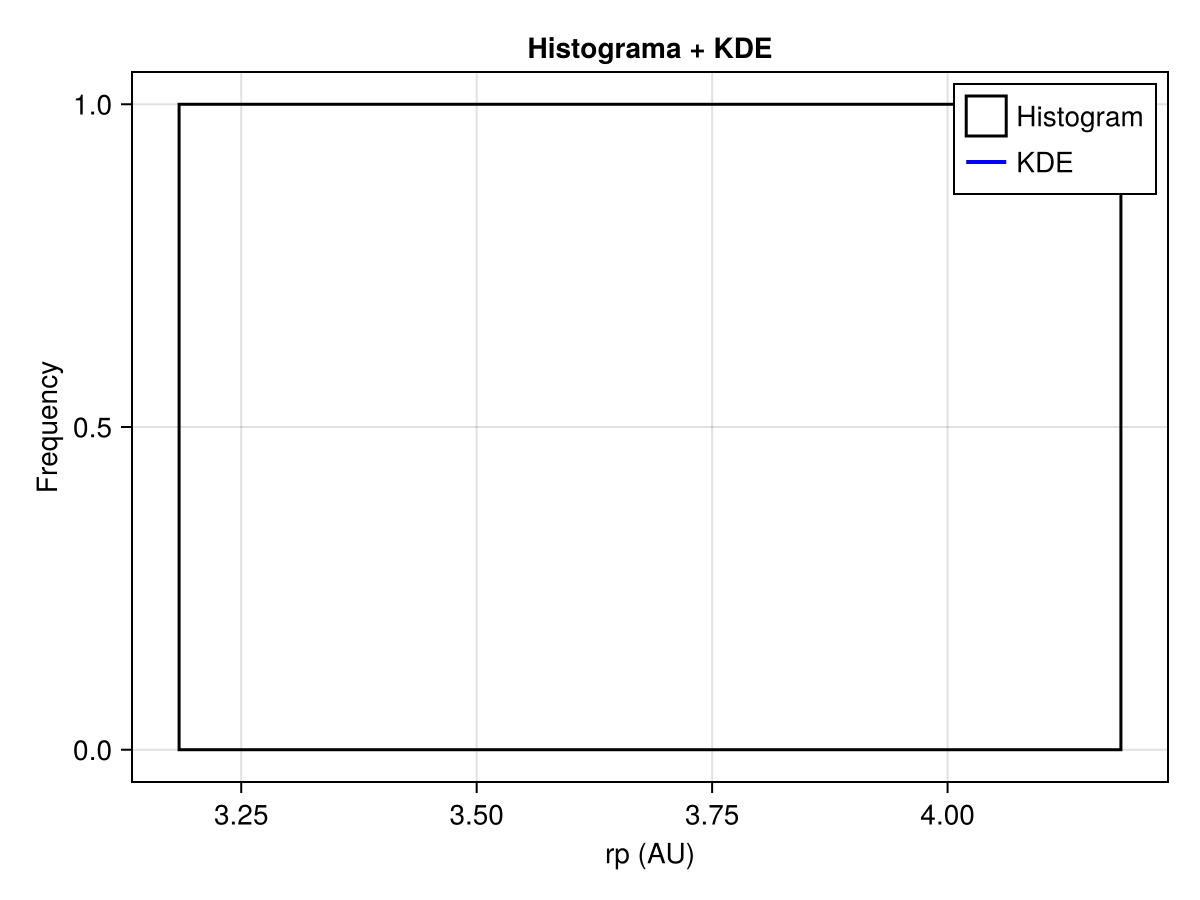

LoadError: ArgumentError: weights cannot contain Inf or NaN values

In [21]:
rp_norm=rp_dist/4.8e-6

p_low, p_high = quantile(rp_norm, [0.1, 0.9])
rp_cut = rp_norm[(rp_norm .>= p_low) .& (rp_norm .<= p_high)]

kde_result = kde(rp_cut)  

x_vals = kde_result.x
pdf_vals = kde_result.density

fig = Figure()
ax = Axis(fig[1, 1]; xlabel="rp (AU)", ylabel="Frequency", title="Histograma + KDE")

# Histogram
hist!(ax, rp_norm; bins=40, normalization=:pdf, color=:transparent, strokecolor=:black, strokewidth=1.5, label="Histogram")

# KDE
lines!(ax, x_vals, pdf_vals; color=:blue, linewidth=2, label="KDE")

axislegend(ax)
display(fig)

pdf_vals_norm = pdf_vals ./ sum(pdf_vals)

samples_rp = sample(x_vals, Weights(pdf_vals_norm), N)
samples_rp

In [ ]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"$R$", ylabel=L"f(R)")

indices_snapshot = [1, 20, 25, 30, 40, 45]
colores = [:blue, :green, :orange, :red, :purple, :brown]

for (i,color) in zip(indices_snapshot, colores)

    t = time[i*40]
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_3_1.0e6/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)

    y_b = snap["f_e"][3][:,20] 
    y_s = snap["f_e"][1][:,20] 
    y_bh = snap["f_e"][2][:,30]
    
    #lines!(ax, R, y_b, linestyle=:dash, color=color, label="Binaries at t = $(round(t, digits=2)) Gyr")
    #lines!(ax, R, y_s, linestyle=:dot, color=color, label="Stars at t = $(round(t, digits=2)) Gyr")
    lines!(ax, R, y_bh, color=color, label="BH at t = $(round(t, digits=2)) Gyr")
end

#xlims!(E[findfirst( aux["rc"] .< 10 * params["rh"] )], E[findfirst( aux["rc"] .< 0.001 * params["rh"] )])
axislegend(
    ax;
    position = :rb,
    orientation = :vertical, 
    nbanks = 1, 
    labelsize = 8, 
    patchsize = (10, 10),   
    framewidth = 0.5    
)

#vlines!(E[findfirst( aux["rc"] .< params["rh"] )])
#text!(L"r_h", position = (1.1 * E[findfirst( aux["rc"] .< params["rh"] )], 0.0001))

save("F(R)_1e6_3comp.pdf", current_figure())

In [ ]:
# a, e , rp distibution , initial and final :)

In [ ]:
f_initial_bi_R = [trapz(E, f_initial_bi[i,:]) for i in 1:length(R)]
f_initial_bi_R = reshape(f_initial_bi_R, length(R))
f_initial_bi_e = f_initial_bi_R * 2 .* sqrt.(-(R.-1))
e_vals=sqrt.(-(R.-1))
fig = Figure(size=(800, 600))
ax = Axis(fig[1,1])
lines!(ax, sqrt.(-(R.-1)) , f_initial_bi_e, color = :red)
display(fig)

In [ ]:
f_initial_bi_E = [trapz(R, f_initial_bi[:,i]) for i in 1:length(E)]
f_initial_bi_E = reshape(f_initial_bi_E, length(E))
f_initial_bi_a = f_initial_bi_E .* abs.(dEda)
fig = Figure(size=(800, 600))
ax = Axis(fig[1,1])
#xlims!(0,0.8)
lines!(ax, log10.(aux["rc"]), f_initial_bi_a, color = :red)
vlines!(log10.(params["rlc"][3]))
display(fig)

In [ ]:
jacobian_matrix = [abs(dEda[i] * (-2 * e)) for i in 1:length(dEda), e in e_vals]
f_initial_bi_ae=f_initial_bi'.*jacobian_matrix[1]
fig = Figure(size=(800, 600))
ax1 = Axis(fig[1,1], xlabel=L"a (pc)", ylabel="e", title="Initial DF for Binaries") 
hm = heatmap!(ax1, log10.(aux["rc"]), e_vals, f_initial_bi_ae; colormap=:viridis, colorrange=(0, maximum(f_initial_bi_ae)))
Colorbar(fig[1,2], hm,  label = L"f")
vlines!(log10.(params["rlc"][3]))
display(fig)


In [ ]:
f_final_bi_ae=f_end_bi'.*jacobian_matrix[1]
fig = Figure(size=(800, 600))
ax1 = Axis(fig[1,1], xlabel=L"a (pc)", ylabel="e", title="Initial DF for Binaries") 
hm = heatmap!(ax1, log10.(aux["rc"]), e_vals, f_final_bi_ae; colormap=:viridis, colorrange=(0, maximum(f_final_bi_ae)))
Colorbar(fig[1,2], hm,  label = L"f")
vlines!(log10.(params["rlc"][3]))
display(fig)

In [ ]:
fig = Figure(size=(800, 600))
ax1 = Axis(fig[1,1], xlabel=L"a (pc)", ylabel="e", title="Differential DF for Binaries") 
hm = heatmap!(ax1, log10.(aux["rc"]), e_vals, (f_final_bi_ae-f_initial_bi_ae); colormap=:viridis, colorrange=(minimum(f_final_bi_ae-f_initial_bi_ae), maximum(f_final_bi_ae-f_initial_bi_ae)))
Colorbar(fig[1,2], hm,  label = L"f")
vlines!(log10.(params["rh"]), color=:black)
display(fig)


In [47]:
sum(sum(TDE_final))/(20)

224.4